<a href="https://colab.research.google.com/github/Shahriar-Rahman-Alvi/Alt_projects/blob/Main/ActionCLIP_Milestone2%263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
!pip install -q transformers opencv-python

In [ ]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model = model.to("cuda")

print("CLIP model loaded successfully!")

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded successfully!


In [ ]:
from PIL import Image
import requests
import torch

# Download a test image
url = "https://images.unsplash.com/photo-1524650359799-842906ca1c06"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Our action prompts
prompts = [
    "a person playing guitar",
    "a person swimming",
    "a person riding a bicycle",
    "a person cooking"
]

inputs = processor(
    text=prompts,
    images=image,
    return_tensors="pt",
    padding=True
)

inputs = {k: v.to("cuda") for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)
    probabilities = outputs.logits_per_image.softmax(dim=1)[0]

for prompt, probability in zip(prompts, probabilities):
    print(f"{prompt}: {probability.item():.4f}")

best_idx = probabilities.argmax().item()
print("\nPrediction:", prompts[best_idx])

a person playing guitar: 0.9996
a person swimming: 0.0002
a person riding a bicycle: 0.0001
a person cooking: 0.0002

Prediction: a person playing guitar


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving AQOlAauZOi1-5MTKUriGq-TOQRAf_fKinTDx282Nu2EqoehjN59D30AAdu0MKtxcBVJtY63J1xSdoYqsaDnHKxD6zqVa_DCe0X5FtrwmmQ.mp4 to AQOlAauZOi1-5MTKUriGq-TOQRAf_fKinTDx282Nu2EqoehjN59D30AAdu0MKtxcBVJtY63J1xSdoYqsaDnHKxD6zqVa_DCe0X5FtrwmmQ.mp4


In [ ]:
import cv2
import os

video_file = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_file)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
duration = frame_count / fps if fps > 0 else 0

print("Video:", video_file)
print("Total frames:", frame_count)
print("FPS:", fps)
print("Duration:", round(duration, 2), "seconds")

cap.release()

Video: AQOlAauZOi1-5MTKUriGq-TOQRAf_fKinTDx282Nu2EqoehjN59D30AAdu0MKtxcBVJtY63J1xSdoYqsaDnHKxD6zqVa_DCe0X5FtrwmmQ.mp4
Total frames: 975
FPS: 25.0
Duration: 39.0 seconds


Extracted frames: 8


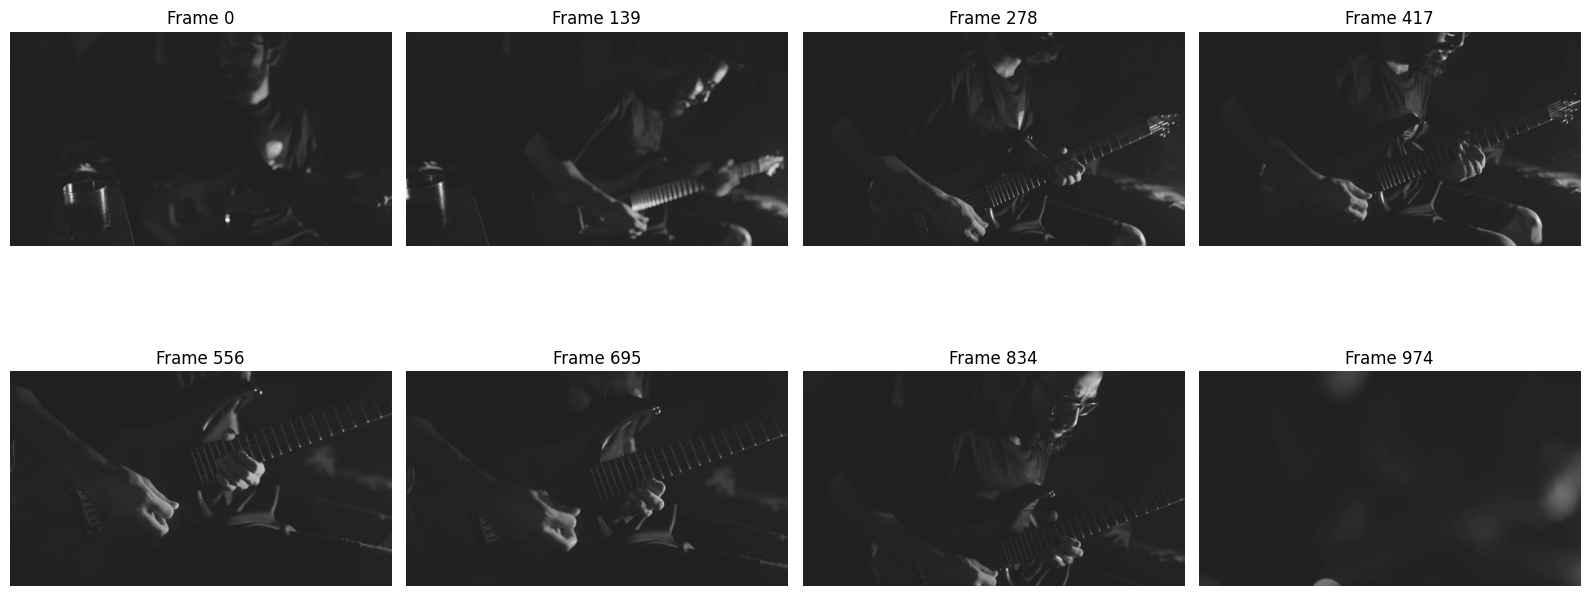

In [ ]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt

video_file = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_file)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Choose 8 evenly spaced frames
frame_indices = [
    int(i * (frame_count - 1) / 7)
    for i in range(8)
]

frames = []

for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    success, frame = cap.read()

    if success:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(Image.fromarray(frame))

cap.release()

print("Extracted frames:", len(frames))

# Display the frames
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, frame, idx in zip(axes.flat, frames, frame_indices):
    ax.imshow(frame)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np

# Different prompt styles for the same action
prompt_groups = {
    "Prompt 1": "a person playing guitar",
    "Prompt 2": "a person is playing guitar",
    "Prompt 3": "a video of a person playing guitar",
    "Prompt 4": "a person performing the action of playing guitar"
}

results = {}

for name, prompt in prompt_groups.items():

    frame_scores = []

    for frame in frames:
        inputs = processor(
            text=[prompt],
            images=frame,
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.to("cuda") for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            score = outputs.logits_per_image[0, 0].item()

        frame_scores.append(score)

    results[name] = np.mean(frame_scores)

print("Average similarity score for each prompt:\n")

for name, score in results.items():
    print(f"{name}: {score:.4f} -> {prompt_groups[name]}")

best_prompt = max(results, key=results.get)

print("\nBest prompt:")
print(prompt_groups[best_prompt])
print(f"Score: {results[best_prompt]:.4f}")

Average similarity score for each prompt:

Prompt 1: 27.3678 -> a person playing guitar
Prompt 2: 27.8668 -> a person is playing guitar
Prompt 3: 28.7593 -> a video of a person playing guitar
Prompt 4: 27.0212 -> a person performing the action of playing guitar

Best prompt:
a video of a person playing guitar
Score: 28.7593


In [ ]:
import numpy as np
import torch

candidate_actions = [
    "playing guitar",
    "swimming",
    "riding a bicycle",
    "cooking",
    "playing basketball",
    "running"
]

prompt_results = {}

for action in candidate_actions:
    prompt = f"a video of a person {action}"
    scores = []

    for frame in frames:
        inputs = processor(
            text=[prompt],
            images=frame,
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.to("cuda") for k, v in inputs.items()}

        with torch.no_grad():
            output = model(**inputs)
            score = output.logits_per_image[0, 0].item()

        scores.append(score)

    prompt_results[action] = np.mean(scores)

print("Action recognition results:\n")

for action, score in sorted(prompt_results.items(), key=lambda x: x[1], reverse=True):
    print(f"{action}: {score:.4f}")

prediction = max(prompt_results, key=prompt_results.get)

print("\nPredicted action:", prediction)

Action recognition results:

playing guitar: 28.7593
running: 22.1683
cooking: 21.3834
riding a bicycle: 21.3158
swimming: 20.8212
playing basketball: 20.3950

Predicted action: playing guitar


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 0812.mp4 to 0812.mp4


In [ ]:
import cv2

video_file = "0812.mp4"

cap = cv2.VideoCapture(video_file)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
duration = frame_count / fps if fps > 0 else 0

print("Video:", video_file)
print("Total frames:", frame_count)
print("FPS:", fps)
print("Duration:", round(duration, 2), "seconds")

cap.release()

Video: 0812.mp4
Total frames: 1998
FPS: 60.0
Duration: 33.3 seconds


Extracted: 12 frames


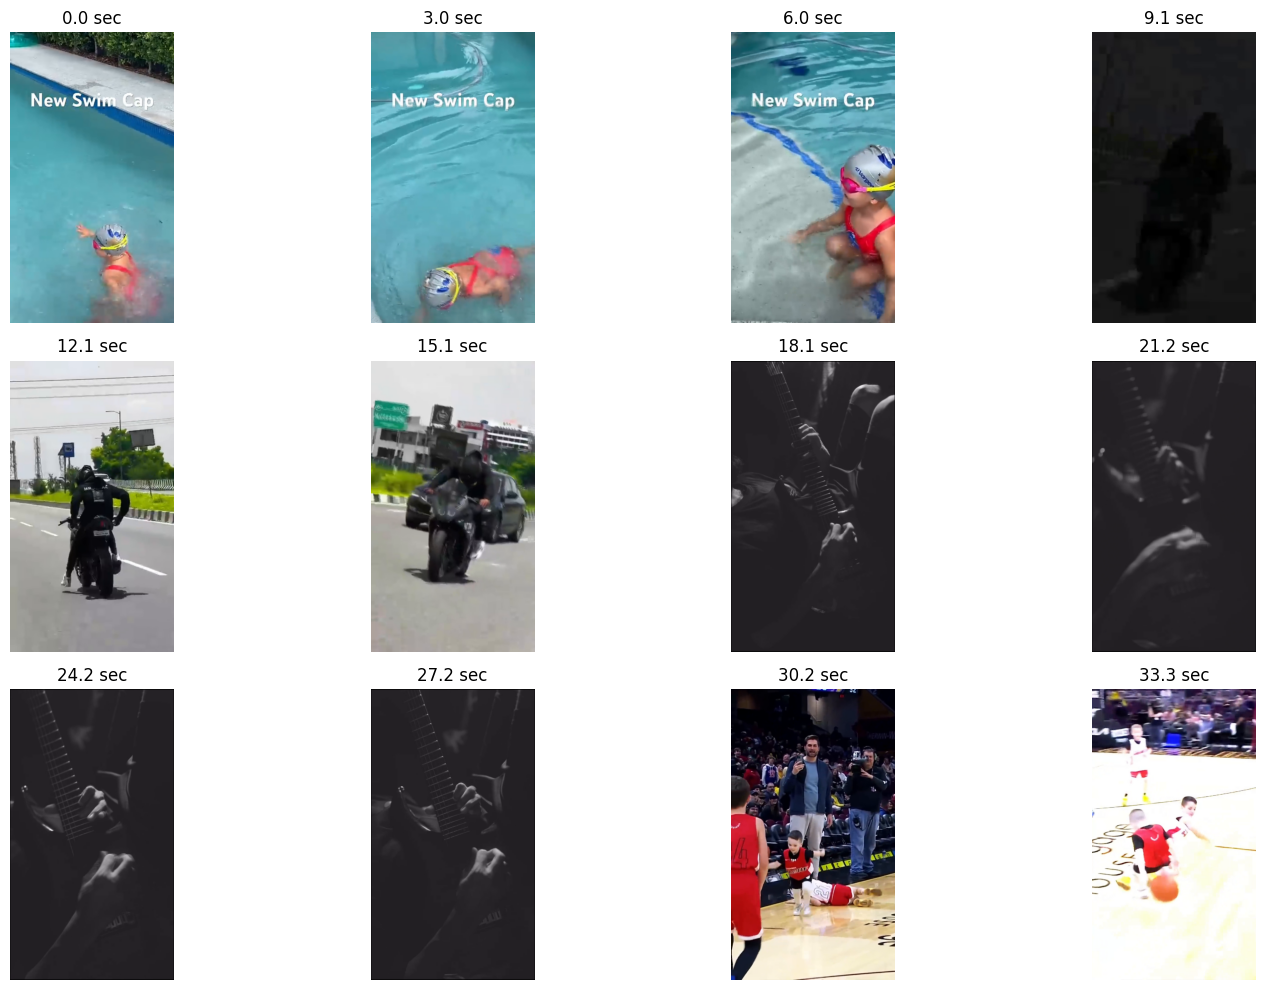

In [ ]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt

video_file = "0812.mp4"

cap = cv2.VideoCapture(video_file)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# 12 evenly spaced frames
frame_indices = [
    int(i * (frame_count - 1) / 11)
    for i in range(12)
]

frames_0812 = []

for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    success, frame = cap.read()

    if success:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames_0812.append(Image.fromarray(frame))

cap.release()

print("Extracted:", len(frames_0812), "frames")

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, frame, idx in zip(axes.flat, frames_0812, frame_indices):
    ax.imshow(frame)
    ax.set_title(f"{idx / 60:.1f} sec")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import torch
from PIL import Image

video_file = "0812.mp4"

# Approximate action segments based on your video
segments = {
    "Swimming": (0, 7),
    "Riding Motorcycle": (10, 17),
    "Playing Guitar": (18, 26)
}

candidate_actions = [
    "swimming",
    "riding a motorcycle",
    "playing guitar"
]

all_results = {}

for segment_name, (start_sec, end_sec) in segments.items():

    cap = cv2.VideoCapture(video_file)
    fps = cap.get(cv2.CAP_PROP_FPS)

    start_frame = int(start_sec * fps)
    end_frame = int(end_sec * fps)

    # Pick 5 frames from this action segment
    frame_indices = np.linspace(
        start_frame,
        end_frame,
        5,
        dtype=int
    )

    segment_frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()

        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            segment_frames.append(Image.fromarray(frame))

    cap.release()

    action_scores = {}

    for action in candidate_actions:

        prompt = f"a video of a person {action}"
        scores = []

        for frame in segment_frames:

            inputs = processor(
                text=[prompt],
                images=frame,
                return_tensors="pt",
                padding=True
            )

            inputs = {
                k: v.to("cuda")
                for k, v in inputs.items()
            }

            with torch.no_grad():
                output = model(**inputs)
                score = output.logits_per_image[0, 0].item()

            scores.append(score)

        action_scores[action] = np.mean(scores)

    all_results[segment_name] = action_scores

    prediction = max(
        action_scores,
        key=action_scores.get
    )

    print("\n" + "=" * 50)
    print("Actual segment:", segment_name)

    for action, score in sorted(
        action_scores.items(),
        key=lambda x: x[1],
        reverse=True
    ):
        print(f"{action}: {score:.4f}")

    print("Prediction:", prediction)



Actual segment: Swimming
swimming: 31.9962
riding a motorcycle: 21.2584
playing guitar: 19.1685
Prediction: swimming

Actual segment: Riding Motorcycle
riding a motorcycle: 31.8518
playing guitar: 21.4841
swimming: 21.3819
Prediction: riding a motorcycle

Actual segment: Playing Guitar
playing guitar: 28.5698
riding a motorcycle: 20.8966
swimming: 20.2970
Prediction: playing guitar


In [ ]:
import cv2

video_file = "0812.mp4"

cap = cv2.VideoCapture(video_file)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps

cap.release()

# Milestone 3 settings
window_size = 3   # analyze 3 seconds at a time
step_size = 2     # move forward 2 seconds

windows = []

start = 0.0

while start < duration:
    end = min(start + window_size, duration)
    windows.append((start, end))
    start += step_size

print("Video duration:", round(duration, 2), "seconds")
print("Number of windows:", len(windows))
print("\nAutomatically generated windows:")

for i, (start, end) in enumerate(windows):
    print(f"Window {i+1}: {start:.1f}s - {end:.1f}s")

Video duration: 33.3 seconds
Number of windows: 17

Automatically generated windows:
Window 1: 0.0s - 3.0s
Window 2: 2.0s - 5.0s
Window 3: 4.0s - 7.0s
Window 4: 6.0s - 9.0s
Window 5: 8.0s - 11.0s
Window 6: 10.0s - 13.0s
Window 7: 12.0s - 15.0s
Window 8: 14.0s - 17.0s
Window 9: 16.0s - 19.0s
Window 10: 18.0s - 21.0s
Window 11: 20.0s - 23.0s
Window 12: 22.0s - 25.0s
Window 13: 24.0s - 27.0s
Window 14: 26.0s - 29.0s
Window 15: 28.0s - 31.0s
Window 16: 30.0s - 33.0s
Window 17: 32.0s - 33.3s


In [ ]:
import os

print("Files in Colab:")
for f in os.listdir("/content"):
    if f.lower().endswith((".mp4", ".mov", ".avi", ".mkv")):
        print(f)

Files in Colab:
0812.mp4
AQOlAauZOi1-5MTKUriGq-TOQRAf_fKinTDx282Nu2EqoehjN59D30AAdu0MKtxcBVJtY63J1xSdoYqsaDnHKxD6zqVa_DCe0X5FtrwmmQ.mp4


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 0812.mp4 to 0812 (1).mp4


In [ ]:
import cv2

video_file = "0812.mp4"

cap = cv2.VideoCapture(video_file)

if not cap.isOpened():
    print("ERROR: Could not open video.")
else:
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frame_count / fps if fps > 0 else 0

    print("Video:", video_file)
    print("FPS:", fps)
    print("Frames:", frame_count)
    print("Duration:", round(duration, 2), "seconds")

cap.release()

Video: 0812.mp4
FPS: 60.0
Frames: 1998
Duration: 33.3 seconds


In [ ]:
import cv2

video_file = "0812.mp4"

cap = cv2.VideoCapture(video_file)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps

cap.release()

# Milestone 3: automatic sliding windows
window_size = 3   # each window is 3 seconds
step_size = 2     # move forward 2 seconds

windows = []

start = 0.0

while start < duration:
    end = min(start + window_size, duration)
    windows.append((start, end))
    start += step_size

print("Video duration:", round(duration, 2), "seconds")
print("Number of windows:", len(windows))
print("\nAutomatically generated windows:")

for i, (start, end) in enumerate(windows):
    print(f"Window {i+1}: {start:.1f}s - {end:.1f}s")

Video duration: 33.3 seconds
Number of windows: 17

Automatically generated windows:
Window 1: 0.0s - 3.0s
Window 2: 2.0s - 5.0s
Window 3: 4.0s - 7.0s
Window 4: 6.0s - 9.0s
Window 5: 8.0s - 11.0s
Window 6: 10.0s - 13.0s
Window 7: 12.0s - 15.0s
Window 8: 14.0s - 17.0s
Window 9: 16.0s - 19.0s
Window 10: 18.0s - 21.0s
Window 11: 20.0s - 23.0s
Window 12: 22.0s - 25.0s
Window 13: 24.0s - 27.0s
Window 14: 26.0s - 29.0s
Window 15: 28.0s - 31.0s
Window 16: 30.0s - 33.0s
Window 17: 32.0s - 33.3s


In [ ]:
import cv2
import numpy as np
from PIL import Image

video_file = "0812.mp4"

# Store frames for every automatically generated window
window_frames = {}

for window_id, (start_sec, end_sec) in enumerate(windows, start=1):

    cap = cv2.VideoCapture(video_file)
    fps = cap.get(cv2.CAP_PROP_FPS)

    start_frame = int(start_sec * fps)
    end_frame = int(end_sec * fps)

    # 3 evenly spaced frames inside this window
    frame_indices = np.linspace(
        start_frame,
        max(start_frame, end_frame - 1),
        3,
        dtype=int
    )

    frames_for_window = []

    for frame_idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        success, frame = cap.read()

        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames_for_window.append(Image.fromarray(frame))

    cap.release()

    window_frames[window_id] = frames_for_window

print("Frames extracted successfully.")

for window_id, frames_in_window in window_frames.items():
    print(
        f"Window {window_id}: "
        f"{len(frames_in_window)} frames"
    )

Frames extracted successfully.
Window 1: 3 frames
Window 2: 3 frames
Window 3: 3 frames
Window 4: 3 frames
Window 5: 3 frames
Window 6: 3 frames
Window 7: 3 frames
Window 8: 3 frames
Window 9: 3 frames
Window 10: 3 frames
Window 11: 3 frames
Window 12: 3 frames
Window 13: 3 frames
Window 14: 3 frames
Window 15: 3 frames
Window 16: 3 frames
Window 17: 3 frames


In [ ]:
import numpy as np
import torch

candidate_actions = [
    "swimming",
    "riding a motorcycle",
    "playing guitar"
]

window_predictions = {}

for window_id, frames_in_window in window_frames.items():

    action_scores = {
        action: []
        for action in candidate_actions
    }

    # Analyze each frame in this time window
    for frame in frames_in_window:

        for action in candidate_actions:

            prompt = f"a video of a person {action}"

            inputs = processor(
                text=[prompt],
                images=frame,
                return_tensors="pt",
                padding=True
            )

            inputs = {
                k: v.to("cuda")
                for k, v in inputs.items()
            }

            with torch.no_grad():
                output = model(**inputs)
                score = output.logits_per_image[0, 0].item()

            action_scores[action].append(score)

    # Average the 3 frame scores
    average_scores = {
        action: np.mean(scores)
        for action, scores in action_scores.items()
    }

    # Select the highest-scoring action
    prediction = max(
        average_scores,
        key=average_scores.get
    )

    start_sec, end_sec = windows[window_id - 1]

    window_predictions[window_id] = {
        "start": start_sec,
        "end": end_sec,
        "scores": average_scores,
        "prediction": prediction
    }

    print(
        f"Window {window_id:02d} "
        f"({start_sec:.1f}s - {end_sec:.1f}s) "
        f"→ {prediction}"
    )

Window 01 (0.0s - 3.0s) → swimming
Window 02 (2.0s - 5.0s) → swimming
Window 03 (4.0s - 7.0s) → swimming
Window 04 (6.0s - 9.0s) → swimming
Window 05 (8.0s - 11.0s) → riding a motorcycle
Window 06 (10.0s - 13.0s) → riding a motorcycle
Window 07 (12.0s - 15.0s) → riding a motorcycle
Window 08 (14.0s - 17.0s) → riding a motorcycle
Window 09 (16.0s - 19.0s) → playing guitar
Window 10 (18.0s - 21.0s) → playing guitar
Window 11 (20.0s - 23.0s) → playing guitar
Window 12 (22.0s - 25.0s) → playing guitar
Window 13 (24.0s - 27.0s) → playing guitar
Window 14 (26.0s - 29.0s) → playing guitar
Window 15 (28.0s - 31.0s) → playing guitar
Window 16 (30.0s - 33.0s) → swimming
Window 17 (32.0s - 33.3s) → swimming


In [ ]:
from transformers import CLIPProcessor, CLIPModel
import torch

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model = model.to("cuda")

print("CLIP model loaded successfully!")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP model loaded successfully!


In [ ]:
import numpy as np
import torch

candidate_actions = [
    "swimming",
    "riding a motorcycle",
    "playing guitar"
]

window_predictions = {}

for window_id, frames_in_window in window_frames.items():

    action_scores = {
        action: []
        for action in candidate_actions
    }

    for frame in frames_in_window:

        for action in candidate_actions:

            prompt = f"a video of a person {action}"

            inputs = processor(
                text=[prompt],
                images=frame,
                return_tensors="pt",
                padding=True
            )

            inputs = {
                k: v.to("cuda")
                for k, v in inputs.items()
            }

            with torch.no_grad():
                output = model(**inputs)
                score = output.logits_per_image[0, 0].item()

            action_scores[action].append(score)

    average_scores = {
        action: np.mean(scores)
        for action, scores in action_scores.items()
    }

    prediction = max(
        average_scores,
        key=average_scores.get
    )

    start_sec, end_sec = windows[window_id - 1]

    window_predictions[window_id] = {
        "start": start_sec,
        "end": end_sec,
        "scores": average_scores,
        "prediction": prediction
    }

    print(
        f"Window {window_id:02d} "
        f"({start_sec:.1f}s - {end_sec:.1f}s) "
        f"→ {prediction}"
    )

Window 01 (0.0s - 3.0s) → swimming
Window 02 (2.0s - 5.0s) → swimming
Window 03 (4.0s - 7.0s) → swimming
Window 04 (6.0s - 9.0s) → swimming
Window 05 (8.0s - 11.0s) → riding a motorcycle
Window 06 (10.0s - 13.0s) → riding a motorcycle
Window 07 (12.0s - 15.0s) → riding a motorcycle
Window 08 (14.0s - 17.0s) → riding a motorcycle
Window 09 (16.0s - 19.0s) → playing guitar
Window 10 (18.0s - 21.0s) → playing guitar
Window 11 (20.0s - 23.0s) → playing guitar
Window 12 (22.0s - 25.0s) → playing guitar
Window 13 (24.0s - 27.0s) → playing guitar
Window 14 (26.0s - 29.0s) → playing guitar
Window 15 (28.0s - 31.0s) → playing guitar
Window 16 (30.0s - 33.0s) → swimming
Window 17 (32.0s - 33.3s) → swimming


In [ ]:
from collections import Counter

# Get the raw predictions in order
raw_predictions = [
    window_predictions[i]["prediction"]
    for i in sorted(window_predictions.keys())
]

print("Raw predictions:")
print(raw_predictions)

# Smooth predictions using a 3-window majority vote
smoothed_predictions = raw_predictions.copy()

for i in range(1, len(raw_predictions) - 1):
    neighborhood = raw_predictions[i-1:i+2]
    majority = Counter(neighborhood).most_common(1)[0][0]
    smoothed_predictions[i] = majority

print("\nSmoothed predictions:")
for i, prediction in enumerate(smoothed_predictions, start=1):
    start, end = windows[i-1]
    print(f"Window {i:02d} ({start:.1f}s - {end:.1f}s) → {prediction}")

Raw predictions:
['swimming', 'swimming', 'swimming', 'swimming', 'riding a motorcycle', 'riding a motorcycle', 'riding a motorcycle', 'riding a motorcycle', 'playing guitar', 'playing guitar', 'playing guitar', 'playing guitar', 'playing guitar', 'playing guitar', 'playing guitar', 'swimming', 'swimming']

Smoothed predictions:
Window 01 (0.0s - 3.0s) → swimming
Window 02 (2.0s - 5.0s) → swimming
Window 03 (4.0s - 7.0s) → swimming
Window 04 (6.0s - 9.0s) → swimming
Window 05 (8.0s - 11.0s) → riding a motorcycle
Window 06 (10.0s - 13.0s) → riding a motorcycle
Window 07 (12.0s - 15.0s) → riding a motorcycle
Window 08 (14.0s - 17.0s) → riding a motorcycle
Window 09 (16.0s - 19.0s) → playing guitar
Window 10 (18.0s - 21.0s) → playing guitar
Window 11 (20.0s - 23.0s) → playing guitar
Window 12 (22.0s - 25.0s) → playing guitar
Window 13 (24.0s - 27.0s) → playing guitar
Window 14 (26.0s - 29.0s) → playing guitar
Window 15 (28.0s - 31.0s) → playing guitar
Window 16 (30.0s - 33.0s) → swimming


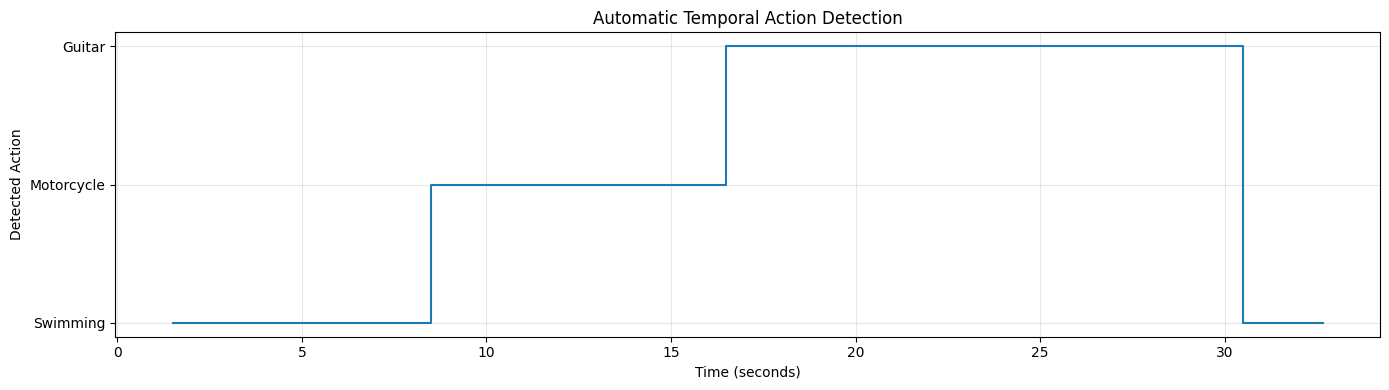

In [ ]:
import matplotlib.pyplot as plt

# Convert smoothed predictions into simple labels
labels = {
    "swimming": "Swimming",
    "riding a motorcycle": "Motorcycle",
    "playing guitar": "Guitar"
}

# Find the center time of each window
times = [
    (start + end) / 2
    for start, end in windows
]

# Map actions to numbers for plotting
action_to_number = {
    "swimming": 0,
    "riding a motorcycle": 1,
    "playing guitar": 2
}

numeric_predictions = [
    action_to_number[p]
    for p in smoothed_predictions
]

plt.figure(figsize=(14, 4))

plt.step(
    times,
    numeric_predictions,
    where="mid"
)

plt.yticks(
    [0, 1, 2],
    ["Swimming", "Motorcycle", "Guitar"]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Detected Action")
plt.title("Automatic Temporal Action Detection")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import cv2

test_video = "0812 (1).mp4"

cap = cv2.VideoCapture(test_video)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps if fps > 0 else 0

cap.release()

print("Test video:", test_video)
print("FPS:", fps)
print("Frames:", frame_count)
print("Duration:", round(duration, 2), "seconds")

Test video: 0812 (1).mp4
FPS: 60.0
Frames: 1998
Duration: 33.3 seconds


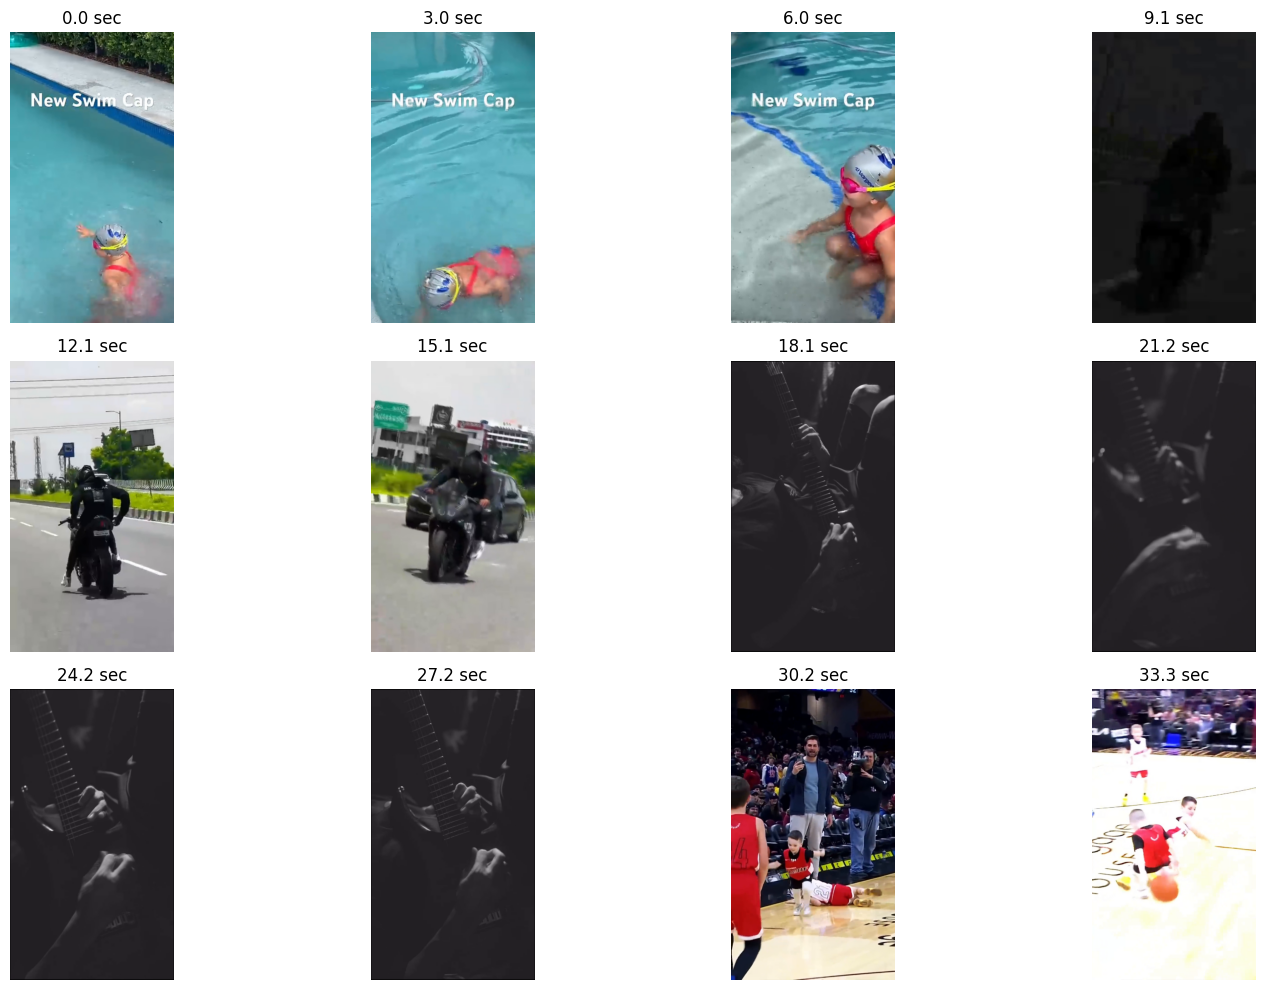

In [ ]:
import cv2
from PIL import Image
import matplotlib.pyplot as plt

test_video = "0812 (1).mp4"

cap = cv2.VideoCapture(test_video)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_indices = [
    int(i * (frame_count - 1) / 11)
    for i in range(12)
]

test_frames = []

for idx in frame_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    success, frame = cap.read()

    if success:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        test_frames.append(Image.fromarray(frame))

cap.release()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for ax, frame, idx in zip(axes.flat, test_frames, frame_indices):
    ax.imshow(frame)
    ax.set_title(f"{idx / 60:.1f} sec")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import cv2

test_video = "0812 (1).mp4"

cap = cv2.VideoCapture(test_video)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps

cap.release()

window_size = 3
step_size = 2

test_windows = []

start = 0.0

while start < duration:
    end = min(start + window_size, duration)
    test_windows.append((start, end))
    start += step_size

print("Test video duration:", round(duration, 2), "seconds")
print("Number of windows:", len(test_windows))

for i, (start, end) in enumerate(test_windows, start=1):
    print(f"Window {i:02d}: {start:.1f}s - {end:.1f}s")

Test video duration: 33.3 seconds
Number of windows: 17
Window 01: 0.0s - 3.0s
Window 02: 2.0s - 5.0s
Window 03: 4.0s - 7.0s
Window 04: 6.0s - 9.0s
Window 05: 8.0s - 11.0s
Window 06: 10.0s - 13.0s
Window 07: 12.0s - 15.0s
Window 08: 14.0s - 17.0s
Window 09: 16.0s - 19.0s
Window 10: 18.0s - 21.0s
Window 11: 20.0s - 23.0s
Window 12: 22.0s - 25.0s
Window 13: 24.0s - 27.0s
Window 14: 26.0s - 29.0s
Window 15: 28.0s - 31.0s
Window 16: 30.0s - 33.0s
Window 17: 32.0s - 33.3s


In [ ]:
import numpy as np
import torch

In [ ]:
candidate_actions = [
    "swimming",
    "riding a motorcycle",
    "playing guitar",
    "playing basketball"
]

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

# Candidate actions shown in the UI
CANDIDATE_ACTIONS = [
    "swimming",
    "riding a motorcycle",
    "playing guitar",
    "playing basketball"
]

def analyze_video(video_path):
    if video_path is None:
        return None, "Please upload a video first.", None

    # -----------------------------
    # 1. Read video information
    # -----------------------------
    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if fps <= 0 or frame_count <= 0:
        cap.release()
        return None, "Could not read the video.", None

    duration = frame_count / fps
    cap.release()

    # -----------------------------
    # 2. Create automatic windows
    # -----------------------------
    window_size = 3
    step_size = 2

    windows = []

    start = 0.0

    while start < duration:
        end = min(start + window_size, duration)
        windows.append((start, end))
        start += step_size

    # -----------------------------
    # 3. Analyze every window
    # -----------------------------
    predictions = []

    for window_id, (start_sec, end_sec) in enumerate(windows, start=1):

        cap = cv2.VideoCapture(video_path)
        start_frame = int(start_sec * fps)
        end_frame = int(end_sec * fps)

        frame_indices = np.linspace(
            start_frame,
            max(start_frame, end_frame - 1),
            3,
            dtype=int
        )

        sampled_frames = []

        for frame_idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
            success, frame = cap.read()

            if success:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                sampled_frames.append(frame)

        cap.release()

        # Skip if no frames were found
        if not sampled_frames:
            continue

        action_scores = {
            action: []
            for action in CANDIDATE_ACTIONS
        }

        # -----------------------------
        # 4. CLIP classification
        # -----------------------------
        for frame in sampled_frames:

            for action in CANDIDATE_ACTIONS:

                prompt = f"a video of a person {action}"

                # Convert OpenCV frame to PIL
                from PIL import Image
                image = Image.fromarray(frame)

                inputs = processor(
                    text=[prompt],
                    images=image,
                    return_tensors="pt",
                    padding=True
                )

                inputs = {
                    k: v.to("cuda")
                    for k, v in inputs.items()
                }

                with torch.no_grad():
                    output = model(**inputs)
                    score = output.logits_per_image[0, 0].item()

                action_scores[action].append(score)

        # Average scores across sampled frames
        average_scores = {
            action: float(np.mean(scores))
            for action, scores in action_scores.items()
        }

        prediction = max(
            average_scores,
            key=average_scores.get
        )

        predictions.append({
            "start": start_sec,
            "end": end_sec,
            "prediction": prediction,
            "scores": average_scores
        })

    # -----------------------------
    # 5. Create result text
    # -----------------------------
    result_lines = []

    result_lines.append(
        f"Video duration: {duration:.1f} seconds"
    )
    result_lines.append(
        f"Analyzed windows: {len(predictions)}"
    )
    result_lines.append("")
    result_lines.append("Detected actions:")

    for item in predictions:
        result_lines.append(
            f"{item['start']:.1f}s - {item['end']:.1f}s"
            f"  →  {item['prediction']}"
        )

    result_text = "\n".join(result_lines)

    # -----------------------------
    # 6. Create timeline graph
    # -----------------------------
    times = [
        (item["start"] + item["end"]) / 2
        for item in predictions
    ]

    action_to_number = {
        "swimming": 0,
        "riding a motorcycle": 1,
        "playing guitar": 2,
        "playing basketball": 3
    }

    numeric_predictions = [
        action_to_number[item["prediction"]]
        for item in predictions
    ]

    fig = plt.figure(figsize=(12, 4))

    plt.step(
        times,
        numeric_predictions,
        where="mid"
    )

    plt.yticks(
        [0, 1, 2, 3],
        [
            "Swimming",
            "Motorcycle",
            "Guitar",
            "Basketball"
        ]
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Detected Action")
    plt.title("Automatic Temporal Action Detection")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Return video, text, graph
    return video_path, result_text, fig

In [ ]:
demo = gr.Interface(
    fn=analyze_video,
    inputs=gr.Video(
        label="Upload a Video"
    ),
    outputs=[
        gr.Video(label="Input Video"),
        gr.Textbox(
            label="Detection Results",
            lines=20
        ),
        gr.Plot(
            label="Action Timeline"
        )
    ],
    title="🎬 Automatic Temporal Action Detection",
    description=(
        "Upload a video containing human actions. "
        "The system automatically analyzes the video in overlapping "
        "time windows and predicts the action happening over time."
    ),
    examples=None
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://09b647ac0cb3ce143a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
